/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 622ms/step - loss: 0.6963
Epoch 2/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.6955
Epoch 3/3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6951


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389 (1.52 KB)

 Trainable params: 129 (516.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 260 (1.02 KB)

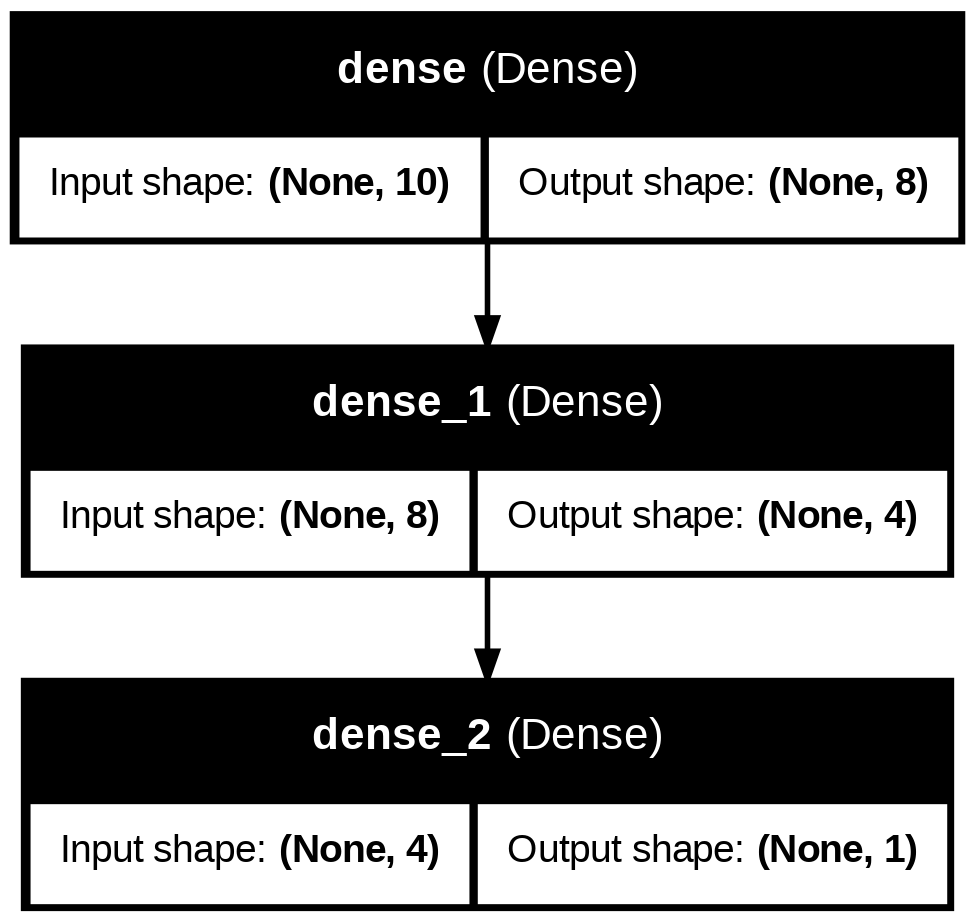

In [ ]:
m# Import libraries
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model

# Generate random data
X = np.random.rand(50, 10)
y = np.random.randint(0, 2, 50)

# Create model
model = Sequential()

model.add(Dense(8, input_dim=10, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy')

# Train modell
model.fit(X, y, epochs=3)

# Show summary
model.summary()

# Plot model
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [ ]:
# Import libraries
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize
X_train = X_train / 255.0

# Reshape
X_train = X_train.reshape(-1, 28, 28, 1)

# Create model
model = models.Sequential()

model.add(layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dropout(0.2))

model.add(layers.Dense(10, activation='softmax'))

# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# Train model
model.fit(X_train, y_train, epochs=3)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.2926
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.1145
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0836


In [ ]:
# Import libraries
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Load dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

# Pad sequences
X_train = pad_sequences(X_train, maxlen=200)

# Create model
model = Sequential()

model.add(Embedding(10000, 32, input_length=200))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy')

# Train model
model.fit(X_train, y_train, epochs=3)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.5678
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 0.3921
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 0.3235


In [ ]:
# Import libraries
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Load dataset
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=10000)

# Pad sequences
X_train = pad_sequences(X_train, maxlen=200)

# Create model
model = Sequential()

model.add(Embedding(10000, 32, input_length=200))
model.add(LSTM(32))
model.add(Dense(46, activation='softmax'))

# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# Train model
model.fit(X_train, y_train, epochs=3)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 2.3676
Epoch 2/3
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.9570
Epoch 3/3
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1.6937


In [ ]:
# Import libraries
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

# Load dataset
(X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=10000)

# Pad sequences
X_train = pad_sequences(X_train, maxlen=200)

# Create model
model = Sequential()

model.add(Embedding(10000, 32, input_length=200))
model.add(GRU(32))
model.add(Dense(46, activation='softmax'))

# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# Train model
model.fit(X_train, y_train, epochs=3)

Epoch 1/3
281/281 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 2.4050
Epoch 2/3
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.8162
Epoch 3/3
281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1.6612


In [ ]:
import torch
# Import libraries
from transformers import BertTokenizer, BertForSequenceClassification
from datasets import load_dataset

# Load dataset
dataset = load_dataset("ag_news")

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize data (only small part)
def tokenize(example):
    return tokenizer(example['text'], padding='max_length', truncation=True)

dataset = dataset.map(tokenize)

# Load model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=4)

# Take small sample
sample = dataset['train'][:4]

# Run model
outputs = model(input_ids=torch.tensor(sample['input_ids']),
                attention_mask=torch.tensor(sample['attention_mask']),
                labels=torch.tensor(sample['label']))

# Print loss


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
print(outputs.loss)

tensor(1.0021, grad_fn=<NllLossBackward0>)


In [ ]:


# PyTorch
import torch

x = torch.tensor([[1.0, 2.0]])
print("PyTorch Tensor:", x)

# OpenCV
import cv2

img = cv2.imread('/content/website.jpg')   # any image file
print("OpenCV Image Loaded")

# Hugging Face Transformers
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
result = classifier("This is good")
print("Transformer Output:", result)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Keras Model Created
PyTorch Tensor: tensor([[1., 2.]])
OpenCV Image Loaded


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Transformer Output: [{'label': 'POSITIVE', 'score': 0.9998360872268677}]


In [ ]:
import tensorflow as tf
from tensorflow import keras

# Load built-in dataset
(x_train, y_train), _ = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0

# Simple model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train (just 1 epoch for demo)
model.fit(x_train, y_train, epochs=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9128 - loss: 0.3063


In [ ]:
# Import library
import numpy as np

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Derivative
def sigmoid_derivative(x):
    return x * (1 - x)

# Input (XOR)
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],[1],[1],[0]])

# Initialize weights
np.random.seed(1)
W1 = np.random.rand(2,2)
W2 = np.random.rand(2,1)

# Training
for i in range(5000):

    # Forward
    hidden = sigmoid(np.dot(X, W1))
    output = sigmoid(np.dot(hidden, W2))

    # Error
    error = y - output

    # Backprop
    d_output = error * sigmoid_derivative(output)
    d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden)

    # Update
    W2 += hidden.T.dot(d_output) * 0.1
    W1 += X.T.dot(d_hidden) * 0.1

# Output
print(output)

[[0.47700457]
 [0.54048263]
 [0.51187691]
 [0.53504145]]
